# Exploratory Data Analysis

## import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

import statsmodels.api as sm

import holidays
import datetime as dt

## define functions

In [2]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1 # , "winter"
    elif month in [3, 4, 5]:
        return 2 # , "spring"
    elif month in [6, 7, 8]:
        return 3 # , "summer"
    else:
        return 4 # , "autumn"
    
def encode_cyclic(df, col, max_val, offset=0):
    df[f"{col}_sin"] = np.sin(2 * np.pi * (df[col] + offset) / max_val)
    df[f"{col}_cos"] = np.cos(2 * np.pi * (df[col] + offset) / max_val)
    return df


## freeze software versions and save as requirements_eda.txt

In [3]:
pip freeze > requirements_eda.txt

Note: you may need to restart the kernel to use updated packages.


## 1. - load datasets

### 1.1 - electrical load

In [4]:
df_load_15min = pd.read_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28.csv", header=None, names=["date_time","load_15min"] )
df_load_15min = df_load_15min[2:]                       # delete first two rows (old headers)
df_load_15min["date_time"] = pd.to_datetime(df_load_15min["date_time"])
df_load_15min = df_load_15min.set_index("date_time")    # set column date_time as index
df_load_15min = df_load_15min.sort_index()              # sort by index (timestamp)
df_load_15min.head(-5)

,load_15min
date_time,
2024-01-01 00:00:00,NaN
2024-01-01 00:15:00,9.48 MW
2024-01-01 00:30:00,9.13 MW
2024-01-01 00:45:00,9.06 MW
2024-01-01 01:00:00,9.13 MW
...,...
2026-02-28 21:30:00,11.48 MW
2026-02-28 21:45:00,11.46 MW
2026-02-28 22:00:00,11.60 MW


## 2. - explore the data

## 2.1 - check the data types of the dataset

In [5]:
df_load_15min.dtypes

load_15min    str
dtype: object

### 2.1.1 - checking the count of missing values per column

In [6]:
df_load_15min.isna().sum()

load_15min    133
dtype: int64

### 2.1.2 - check for missing timestamps

In [7]:
# expect exactly one value every 15 min from first to last timestamp
expected = pd.date_range(df_load_15min.index.min(), df_load_15min.index.max(), freq="15min")

# collect missing timestamps -> available in "expected", but not in the DataFrame
missing = expected.difference(df_load_15min.index)

print(f"count of missing 15 min timestamps: {len(missing)}")
display(pd.DataFrame(missing[:20],columns=["missing timestamps"]))  # show first 20 missing timestamps


count of missing 15 min timestamps: 8


,missing timestamps
0,2024-03-31 02:00:00
1,2024-03-31 02:15:00
2,2024-03-31 02:30:00
3,2024-03-31 02:45:00
4,2025-03-30 02:00:00
5,2025-03-30 02:15:00
6,2025-03-30 02:30:00
7,2025-03-30 02:45:00


**missing timestamps always during the change from winter to summer time**
- 2 a.m. -> 3 a.m.

### check for duplicated timestamps

In [8]:
# expect exactly one value every 15 min from first to last timestamp -> store duplicates
duplicates = df_load_15min.index[df_load_15min.index.duplicated()].rename(None)

print(f"count of duplicated 15 min timestamps: {len(duplicates)}")
display(pd.DataFrame(duplicates[:20],columns=["duplicated timestamps"]))  # show first 20 duplicated timestamps

count of duplicated 15 min timestamps: 8


,duplicated timestamps
0,2024-10-27 02:00:00
1,2024-10-27 02:15:00
2,2024-10-27 02:30:00
3,2024-10-27 02:45:00
4,2025-10-26 02:00:00
5,2025-10-26 02:15:00
6,2025-10-26 02:30:00
7,2025-10-26 02:45:00


**duplicated timestamps always during the change from summer to winter time**
- 3 a.m. -> 2 a.m.

## 3. - data cleaning

### 3.1 - handle duplicates
- delete timestamp duplicates




In [9]:
df_load_15min = df_load_15min[~df_load_15min.index.duplicated(keep="first")]    # delete duplicated rows

#check for duplicates again
duplicates = df_load_15min.index[df_load_15min.index.duplicated()].rename(None)

print(f"count of duplicated 15 min timestamps: {len(duplicates)}")
display(pd.DataFrame(duplicates[:20],columns=["duplicated timestamps"]))  # show first 20 duplicated timestamps

count of duplicated 15 min timestamps: 0


,duplicated timestamps


### 3.2 - handle dtypes
- change load value from string to int

In [10]:
df_load_15min.head()

,load_15min
date_time,
2024-01-01 00:00:00,NaN
2024-01-01 00:15:00,9.48 MW
2024-01-01 00:30:00,9.13 MW
2024-01-01 00:45:00,9.06 MW
2024-01-01 01:00:00,9.13 MW


In [11]:
col = "load_15min"          # set column name
old_col = f"{col}_old"      # set column name + "_old"

if old_col not in df_load_15min.columns:                # avoid multiplying by 1000 again and again
    
    df_load_15min[old_col] = df_load_15min[col]         # save old column (including the values)

    # calculate new column
    df_load_15min[col] = (
        pd.to_numeric(
            df_load_15min[col]
              .astype(str)                              # make sure that all values are strings
              .str.replace(",", ".", regex=False)       # if it exists, replace decimal separator ("," with ".")
              .str.extract(r"([-+]?\d*\.?\d+)")[0],     # extract only the first number out of the string
            errors="coerce"
        )
        .mul(1000)          # change unit (MW to kW)
        .round()            # avoid rounding error by multiplying in the previous row
        .astype("Int64")    # int64 because i don't want an error for the NaN values
    )
else:
    print(f"Column '{old_col}' is already existing → nothing changed")


df_load_15min.head()

,load_15min,load_15min_old
date_time,,
2024-01-01 00:00:00,<NA>,NaN
2024-01-01 00:15:00,9480,9.48 MW
2024-01-01 00:30:00,9130,9.13 MW
2024-01-01 00:45:00,9060,9.06 MW
2024-01-01 01:00:00,9130,9.13 MW


### 3.3 - handle outliers

**being an expert in the field, i can say:**
- The values in the lower range are not outliers!
    - Most of these are caused by lower production capacity utilization, and some extreme cases can be attributed to power outages.
- The values in the upper range are all outliers!
    - All were recorded due to errors in the measuring equipment. It is not possible to draw such a high electrical load at the site.
        - Delete all and fill the gap linearly between the last and next existing value.

#### 3.3.1 - create boxplot

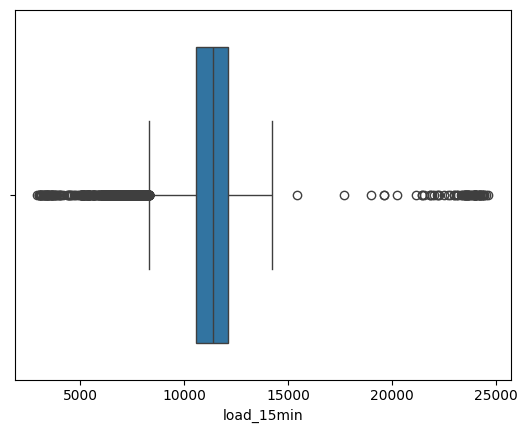

In [12]:
col = "load_15min"

sns.boxplot(x=col, data = df_load_15min)                            
plt.show()

#### 3.3.1 - find min value

In [13]:
col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_load_15min[col].min()
min_ts  = df_load_15min[col].idxmin()

# 2) Position (Integer-Index) of the timestamp
loc = df_load_15min.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_load_15min.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting

def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Min load value: {min_val} kW")
print(f"Min load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

Min load value: 2930 kW
Min load timestamp: 2024-06-19 08:45:00



,load_15min,load_15min_old
date_time,,
2024-06-19 06:15:00,5010,5.01 MW
2024-06-19 06:30:00,4990,4.99 MW
2024-06-19 06:45:00,5060,5.06 MW
2024-06-19 07:00:00,4680,4.68 MW
2024-06-19 07:15:00,4550,4.55 MW
2024-06-19 07:30:00,4340,4.34 MW
2024-06-19 07:45:00,3730,3.73 MW
2024-06-19 08:00:00,3110,3.11 MW
2024-06-19 08:15:00,3030,3.03 MW


#### 3.3.2 - find max value

In [14]:
col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_load_15min[col].max()
min_ts  = df_load_15min[col].idxmax()

# 2) Position (Integer-Index) of the timestamp
loc = df_load_15min.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_load_15min.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting
def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Max load value: {min_val} kW")
print(f"Max load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

Max load value: 24650 kW
Max load timestamp: 2025-12-17 07:00:00



,load_15min,load_15min_old
date_time,,
2025-12-17 04:30:00,23650,23.65 MW
2025-12-17 04:45:00,24240,24.24 MW
2025-12-17 05:00:00,24230,24.23 MW
2025-12-17 05:15:00,23840,23.84 MW
2025-12-17 05:30:00,23980,23.98 MW
2025-12-17 05:45:00,23960,23.96 MW
2025-12-17 06:00:00,23670,23.67 MW
2025-12-17 06:15:00,23550,23.55 MW
2025-12-17 06:30:00,23730,23.73 MW


#### 3.3.3 - delete outliers
- Delete all outliers only at the upper limit (> 15MW)

In [15]:
df_load_15min.isna().sum()

load_15min        130
load_15min_old    130
dtype: int64

In [16]:
df_load_15min_clean = df_load_15min.copy()

#############################################
# delete outliers > 15000 (→ NaN)
#############################################
df_load_15min_clean.loc[df_load_15min_clean["load_15min"] > 15000, "load_15min"] = pd.NA

In [17]:
df_load_15min_clean.isna().sum()

load_15min        204
load_15min_old    130
dtype: int64

Max load value: 14230 kW
Max load timestamp: 2026-02-16 12:30:00



,load_15min,load_15min_old
date_time,,
2026-02-16 10:00:00,12380,12.38 MW
2026-02-16 10:15:00,12420,12.42 MW
2026-02-16 10:30:00,12650,12.65 MW
2026-02-16 10:45:00,13110,13.11 MW
2026-02-16 11:00:00,13060,13.06 MW
2026-02-16 11:15:00,12750,12.75 MW
2026-02-16 11:30:00,12600,12.60 MW
2026-02-16 11:45:00,12700,12.70 MW
2026-02-16 12:00:00,12900,12.90 MW


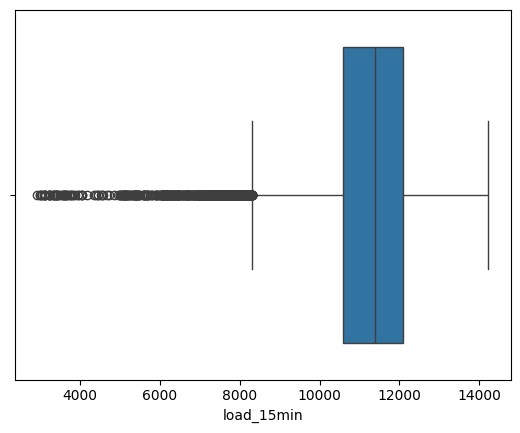

In [18]:
# checking for the highest value again after deleting the outliers

col = "load_15min"

# 1) Minimum value and timestamp of minimum value
min_val = df_load_15min_clean[col].max()
min_ts  = df_load_15min_clean[col].idxmax()

# 2) Position (Integer-Index) of the timestamp
loc = df_load_15min_clean.index.get_loc(min_ts)

# 3) create window ±10 values regarding the minimum value timestamp
window = df_load_15min_clean.iloc[max(loc-10, 0):loc+11]

# 4) define color highlighting
def highlight_min_row(s):
    return [
        "background-color: yellow; color: black;" if idx == min_ts else ""
        for idx in s.index
    ]

# 5) output
print(f"Max load value: {min_val} kW")
print(f"Max load timestamp: {min_ts}\n")

display(window.style.apply(highlight_min_row, axis=0))

sns.boxplot(x=col, data = df_load_15min_clean)                            
plt.show()

### 3.4 - handle missing values
- fill the gaps linearly between the last and next existing value.

In [19]:
# check count of NaN values before filling the gaps
print(df_load_15min_clean.isna().sum())

load_15min        204
load_15min_old    130
dtype: int64


In [20]:
#############################################
# fill gaps linear 
#############################################
df_load_15min_clean["load_15min"] = (
    df_load_15min_clean["load_15min"]
        .interpolate(method="time", limit_direction="both")   # fill in both directions to fill the beginning and end to
        .round()
        .astype("Int64")              # change float + NaN → Int64 + <NA>
)

In [21]:
# check count of NaN values after filling the gaps
print(df_load_15min_clean.isna().sum())

load_15min          0
load_15min_old    130
dtype: int64


In [22]:
# check all old NaN values and the values they have now
df_load_15min_clean[df_load_15min_clean["load_15min_old"].isna()]


,load_15min,load_15min_old
date_time,,
2024-01-01 00:00:00,9480,NaN
2024-10-11 00:45:00,11365,NaN
2024-10-11 19:30:00,11595,NaN
2024-10-17 04:30:00,10710,NaN
2024-10-18 17:30:00,12395,NaN
...,...,...
2026-02-07 23:15:00,11745,NaN
2026-02-09 22:30:00,11810,NaN
2026-02-10 10:30:00,10330,NaN


### 3.5 - drop columns

In [23]:
df_load_15min_clean.head()

,load_15min,load_15min_old
date_time,,
2024-01-01 00:00:00,9480,NaN
2024-01-01 00:15:00,9480,9.48 MW
2024-01-01 00:30:00,9130,9.13 MW
2024-01-01 00:45:00,9060,9.06 MW
2024-01-01 01:00:00,9130,9.13 MW


In [24]:
df_load_15min_clean = df_load_15min_clean.drop(columns="load_15min_old")

In [25]:
df_load_15min_clean.head()

,load_15min
date_time,
2024-01-01 00:00:00,9480
2024-01-01 00:15:00,9480
2024-01-01 00:30:00,9130
2024-01-01 00:45:00,9060
2024-01-01 01:00:00,9130


## 4. - visualize some data

### 4.1 - outliers - before and after cleaning

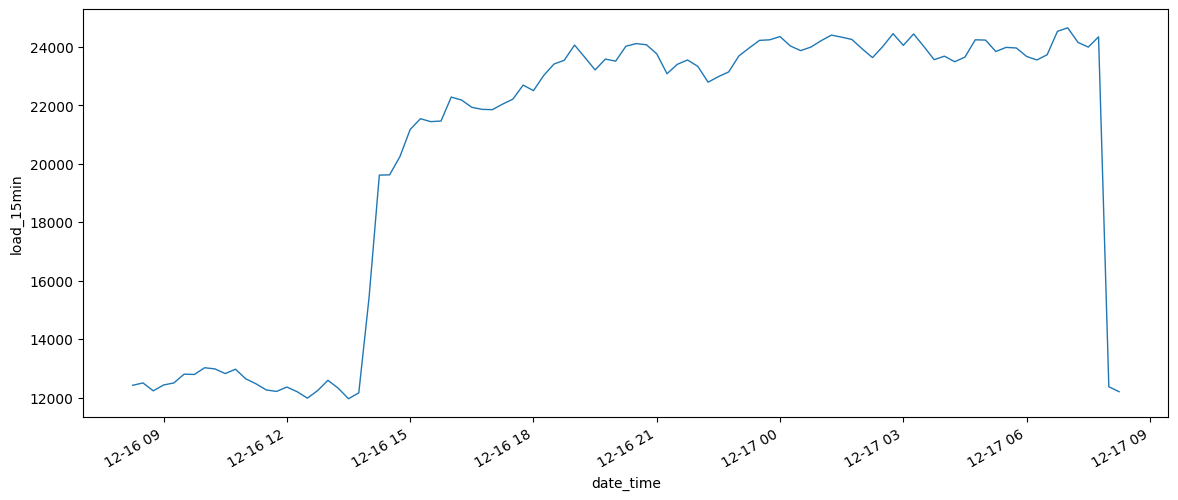

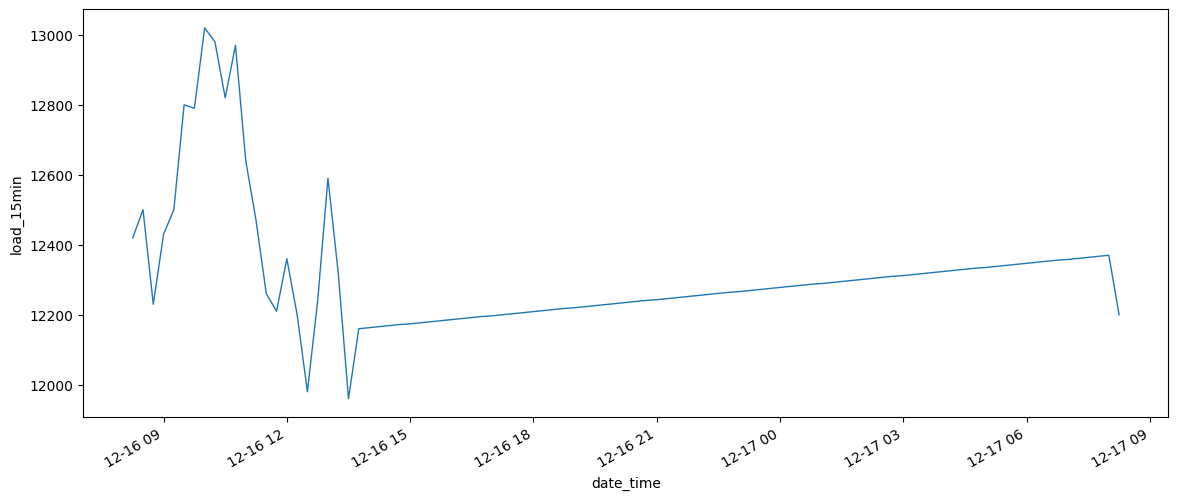

In [26]:
start_date = "2025-12-16 08:15:00	"     # only year "2024" -> a specific month "2024-1" -> a specific day "2024-1-30"
end_date = "2025-12-17 08:15:00	"

# select time period
df_plot = df_load_15min.loc[start_date:end_date]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_plot,
             x="date_time",
             y="load_15min",
             linewidth=1.0
             )

plt.gcf().autofmt_xdate()       # automatically format and rotate the date
plt.show()

df_plot = df_load_15min_clean.loc[start_date:end_date]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_plot,
             x="date_time",
             y="load_15min",
             linewidth=1.0
             )

plt.gcf().autofmt_xdate()       # automatically format and rotate the date
plt.show()

### 4.2 - including a line for the daily, monthly, yearly average to see the trend

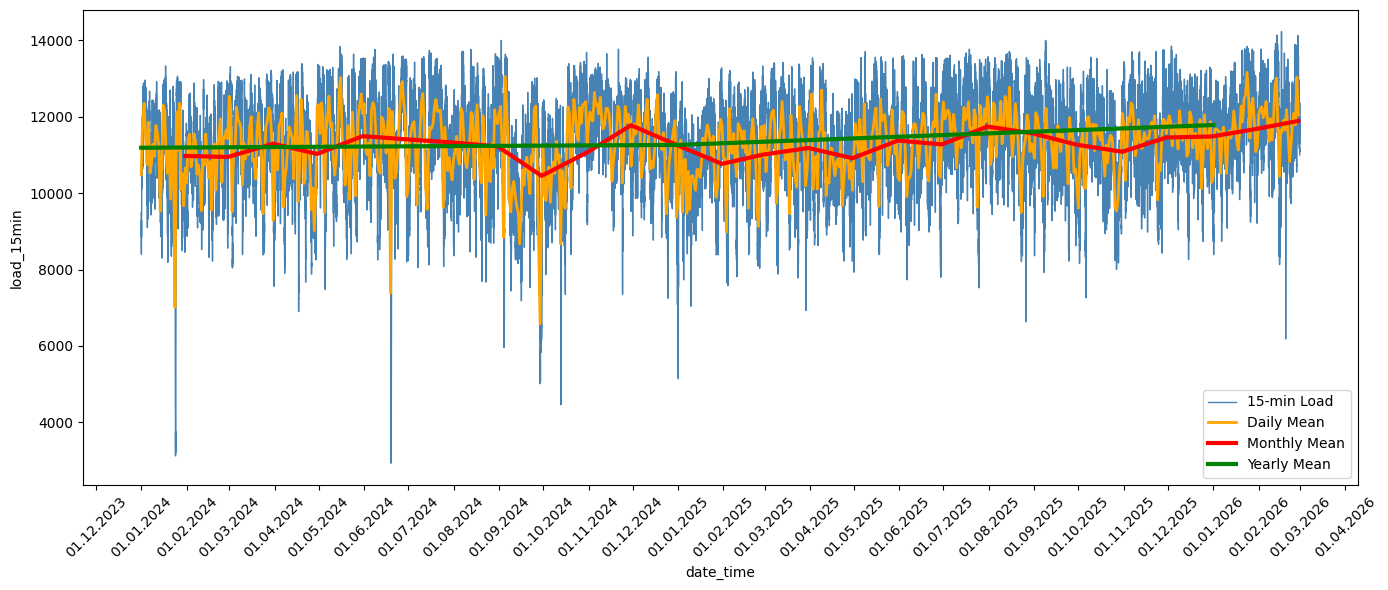

In [27]:
start_date = "2024"     # only year "2024" -> a specific month "2024-1" -> a specific day "2024-1-30"
end_date = "2026"

# select time period
df_plot = df_load_15min_clean.loc[start_date:end_date]

# calculate montly averages
df_monthly_average = df_plot["load_15min"].resample("ME").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)
# calculate yearly averages
df_yearly_average = df_plot["load_15min"].resample("YS").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)
# calculate yearly averages
df_daily_average = df_plot["load_15min"].resample("D").mean()   # D - daily average; ME -> monthly average (assign to the last day (E=end) of the month)


plt.figure(figsize=(14,6))

# main line (15-min values)
sns.lineplot(
    data=df_plot.reset_index(),
    x="date_time",
    y="load_15min",
    linewidth=1.0,
    color="steelblue",
    label="15-min Load"
)

# daily averages
sns.lineplot(
    x=df_daily_average.index,
    y=df_daily_average.values,
    linewidth=2.0,
    color="orange",
    label="Daily Mean"
)

# monthly averages
sns.lineplot(
    x=df_monthly_average.index,
    y=df_monthly_average.values,
    linewidth=3.0,
    color="red",
    label="Monthly Mean"
)

# yearly averages
sns.lineplot(
    x=df_yearly_average.index,
    y=df_yearly_average.values,
    linewidth=3.0,
    color="green",
    label="Yearly Mean"
)


# customized date axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))     # display only day point per month on x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
plt.xticks(rotation=45)
# plt.gcf().autofmt_xdate()         # automatically format and rotate the date

plt.tight_layout()
plt.legend()
plt.show()


### 4.3 - histplot -> load distribution 

<Axes: xlabel='load_15min', ylabel='Count'>

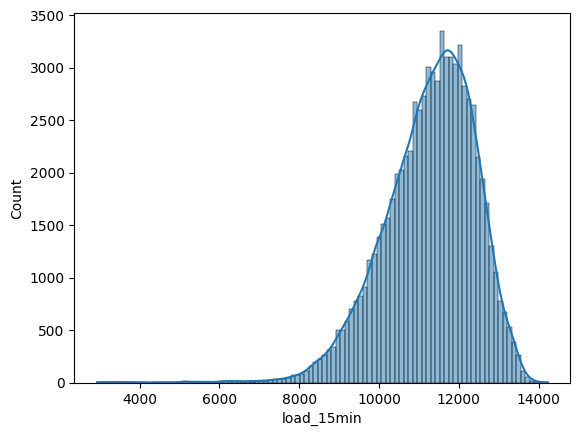

In [28]:
sns.histplot(x = df_load_15min_clean["load_15min"], bins=100, kde=True)  

## 5. - feature engineering
**!!! change time to utc !!!**                  🔲

**add columns:**
- split time/date                                 
    - hour (cyclical encoding)                  ✅
    - minute (cyclical encoding)                ✅
    - month (cyclical encoding)                 ✅
    - season (cyclical encoding)                ✅
- weekday (3 versions)
    - weekday (0 = monday ... 6 = sunday)       ✅
    - weekday (one hot encoding)                ✅
    - weekday (cyclical encoding)               ✅
- weekend (1/0)                                 ✅
- public holidays (1/0)                         ✅
- bridging day (1/0)                            ✅
- shifts
    - early shift (1/0)                         ✅
    - late shift (1/0)                          ✅
    - night shift (1/0)                         ✅
- shift change (13-15, 21-23, 5-7)
    - shift change early -> late (0/1 = 13-15)  ✅
    - shift change late -> night (0/1 = 21-23)  ✅
    - shift change night -> early (0/1 = 5-7)   ✅
- load x hours ago                              
    - load_1h_ago                               ✅
    - load_2h_ago                               ✅
    - load_24h_ago                              ✅
    - load_168h_ago                             ✅
- rolling mean -> last x hours
    - rolling_mean_3h                           ✅
    - rolling_mean_6h                           ✅
    - rolling_mean_12h                          ✅
- rolling std -> last x hours
    - rolling_std_3h                            ✅
    - rolling_std_6h                            ✅
    - rolling_std_12h                           ✅






🚀 typical must-haves
For a good forecast, the following are usually still missing:


🌦️ Weather data (if available)
Important for real electricity load:

Temperature (and lags)
Heating/cooling degree days (HDD/CDD)
Wind speed
Solar radiation/cloud cover
Precipitation

🔌 System and trend data

Trend factors (consumption increases/decreases over the years)
Event indicators (e.g., production plan, but only if relevant)

### 5.1 - create colums for time/date (hours, minutes, month)
- ordinal -> better for tree based models
    - 0 - 23 -> hours
    - 0 - 59 -> minutes
    - 1 - 12 -> month
    - 1 - 4 -> season (1= winter ...)
- one hot encoding -> doesn't make sense, based on the number of values
- cyclical encoding -> best for timeseries data and forecasting
    - hour_sin
    - hour_cos
    - hour_sin
    - hour_cos
    - month_sin
    - month_cos
    - season_sin
    - season_cos
    - the model understands that midnight (0) is close to 11 p.m. (23) and also close to 1 a.m. (1)

In [29]:
# hour of the day (0 - 23)
df_load_15min_clean["hour"] = df_load_15min_clean.index.hour
# minute of the hour (0 - 59)
df_load_15min_clean["minute"] = df_load_15min_clean.index.minute
# time of day in minutes (0 - 1439)
df_load_15min_clean["time"] = df_load_15min_clean["hour"] * 60 + df_load_15min_clean["minute"]
# month of the year (1 - 12)
df_load_15min_clean["month"] = df_load_15min_clean.index.month
# season (1=winter; ... ; 4=autumn)
df_load_15min_clean["season"] = df_load_15min_clean.index.month.map(get_season)
df_load_15min_clean.head(22000)

,load_15min,hour,minute,time,month,season
date_time,,,,,,
2024-01-01 00:00:00,9480,0,0,0,1,1
2024-01-01 00:15:00,9480,0,15,15,1,1
2024-01-01 00:30:00,9130,0,30,30,1,1
2024-01-01 00:45:00,9060,0,45,45,1,1
2024-01-01 01:00:00,9130,1,0,60,1,1
...,...,...,...,...,...,...
2024-08-17 03:45:00,12000,3,45,225,8,3
2024-08-17 04:00:00,11630,4,0,240,8,3
2024-08-17 04:15:00,11700,4,15,255,8,3


In [30]:
# hour of the day (0 - 23) -> transform to sine and cosine
df_load_15min_clean = encode_cyclic(df_load_15min_clean,"hour", 24)
# minute of the hours (0 - 59) -> transform to sine and cosine
df_load_15min_clean = encode_cyclic(df_load_15min_clean,"minute", 60)
# time of day in minutes (0 - 1439) -> transform to sine and cosine
df_load_15min_clean = encode_cyclic(df_load_15min_clean,"time", 24*60)
# month (1 - 12) -> transform to sine and cosine
df_load_15min_clean = encode_cyclic(df_load_15min_clean,"month", 24*60, offset=-1)
# season (1 - 4) -> transform to sine and cosine
df_load_15min_clean = encode_cyclic(df_load_15min_clean,"season", 4, offset=-1)

df_load_15min_clean.head()

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos
date_time,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9480,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0
2024-01-01 00:15:00,9480,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0
2024-01-01 00:30:00,9130,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0
2024-01-01 00:45:00,9060,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0
2024-01-01 01:00:00,9130,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0


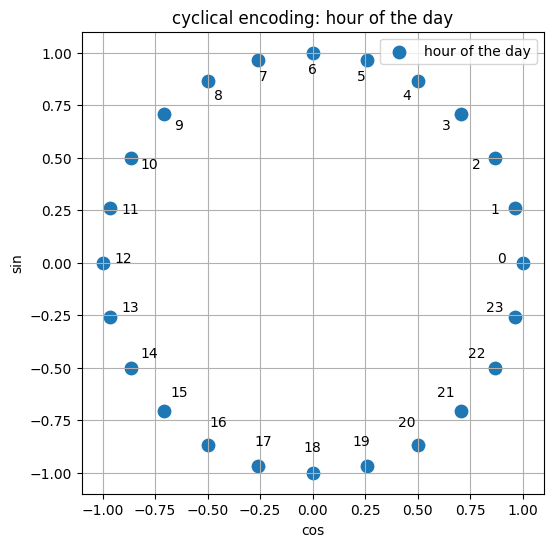

In [31]:
count = 24

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='hour of the day')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: hour of the day")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

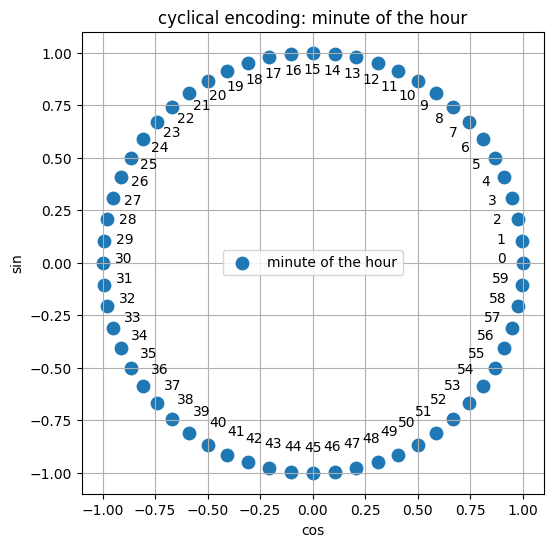

In [32]:
count = 60

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='minute of the hour')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: minute of the hour")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

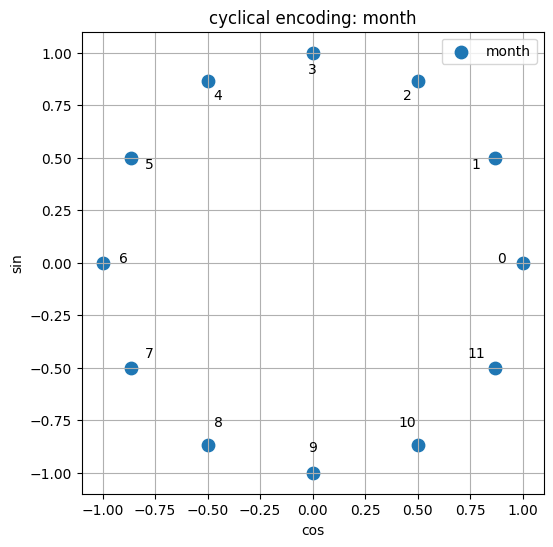

In [33]:
count = 12

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='month')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: month")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

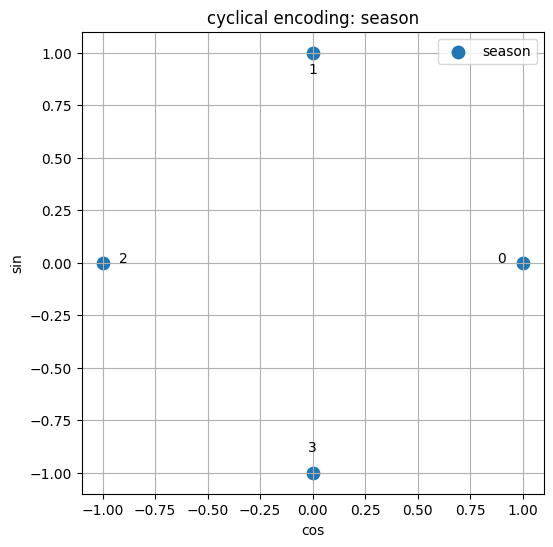

In [34]:
count = 4

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='season')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding: season")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

### 5.2 - create columns "load x hours ago" + "rolling mean last x hours" + "rolling std last x hours"
- load_1h_ago
- load_2h_ago
- load_24h_ago
- load_168h_ago

- rolling_mean_3h
- rolling_mean_6h
- rolling_mean_12h

- rolling_std_3h
- rolling_std_6h
- rolling_std_12h


#### 5.2.1 - load x hours ago

In [35]:
# we have 4 values for each hour -> value 2 hours -> shift by 4 values multiplied by 2 hours
df_load_15min_clean["load_1h_ago"] = df_load_15min_clean["load_15min"].shift(1*4)
df_load_15min_clean["load_2h_ago"] = df_load_15min_clean["load_15min"].shift(2*4)
df_load_15min_clean["load_24h_ago"] = df_load_15min_clean["load_15min"].shift(24*4)
df_load_15min_clean["load_168h_ago"] = df_load_15min_clean["load_15min"].shift(168*4)


#### 5.2.2 - rolling mean last x hours

In [36]:
# we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
df_load_15min_clean["rolling_mean_3h"] = df_load_15min_clean["load_15min"].rolling(window=3*4).mean()
df_load_15min_clean["rolling_mean_6h"] = df_load_15min_clean["load_15min"].rolling(window=6*4).mean()
df_load_15min_clean["rolling_mean_12h"] = df_load_15min_clean["load_15min"].rolling(window=12*4).mean()
df_load_15min_clean.head(12)

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h
date_time,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9480,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 00:15:00,9480,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 00:30:00,9130,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 00:45:00,9060,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 01:00:00,9130,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,9480,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 01:15:00,9050,1,15,75,1,1,0.258819,0.965926,1.000000e+00,2.832769e-16,0.321439,0.946930,0.0,1.0,0.0,1.0,9480,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 01:30:00,8960,1,30,90,1,1,0.258819,0.965926,5.665539e-16,-1.000000e+00,0.382683,0.923880,0.0,1.0,0.0,1.0,9130,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 01:45:00,8950,1,45,105,1,1,0.258819,0.965926,-1.000000e+00,-1.836970e-16,0.442289,0.896873,0.0,1.0,0.0,1.0,9060,<NA>,<NA>,<NA>,NaN,NaN,NaN
2024-01-01 02:00:00,8610,2,0,120,1,1,0.500000,0.866025,0.000000e+00,1.000000e+00,0.500000,0.866025,0.0,1.0,0.0,1.0,9130,9480,<NA>,<NA>,NaN,NaN,NaN


#### 5.2.3 - rolling std last x hours

In [37]:
# we have 4 values for each hour -> mean last 6 hours -> roll by 4 values multiplied by 6 hours
df_load_15min_clean["rolling_std_3h"] = df_load_15min_clean["load_15min"].rolling(window=3*4).std()
df_load_15min_clean["rolling_std_6h"] = df_load_15min_clean["load_15min"].rolling(window=6*4).std()
df_load_15min_clean["rolling_std_12h"] = df_load_15min_clean["load_15min"].rolling(window=12*4).std()
df_load_15min_clean.head(12)

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,9480,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:15:00,9480,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:30:00,9130,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:45:00,9060,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,9130,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,9480,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:15:00,9050,1,15,75,1,1,0.258819,0.965926,1.000000e+00,2.832769e-16,0.321439,0.946930,0.0,1.0,0.0,1.0,9480,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:30:00,8960,1,30,90,1,1,0.258819,0.965926,5.665539e-16,-1.000000e+00,0.382683,0.923880,0.0,1.0,0.0,1.0,9130,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:45:00,8950,1,45,105,1,1,0.258819,0.965926,-1.000000e+00,-1.836970e-16,0.442289,0.896873,0.0,1.0,0.0,1.0,9060,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,8610,2,0,120,1,1,0.500000,0.866025,0.000000e+00,1.000000e+00,0.500000,0.866025,0.0,1.0,0.0,1.0,9130,9480,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


#### 5.2.4 - delete NaN rows -> for the first rows there is no historical data

**based on the "load_168h_ago", we will lose 168*4=672 rows from the beginning of the dataset**

In [38]:
df_load_15min_clean.isna().sum()

load_15min            0
hour                  0
minute                0
time                  0
month                 0
season                0
hour_sin              0
hour_cos              0
minute_sin            0
minute_cos            0
time_sin              0
time_cos              0
month_sin             0
month_cos             0
season_sin            0
season_cos            0
load_1h_ago           4
load_2h_ago           8
load_24h_ago         96
load_168h_ago       672
rolling_mean_3h      11
rolling_mean_6h      23
rolling_mean_12h     47
rolling_std_3h       11
rolling_std_6h       23
rolling_std_12h      47
dtype: int64

In [39]:
# here are no historical values for the first lines -> delete NaN rows -> only in these four columns
df_load_15min_clean = df_load_15min_clean.dropna(subset=["load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago"])
df_load_15min_clean = df_load_15min_clean.dropna(subset=["rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h"]) 
df_load_15min_clean = df_load_15min_clean.dropna(subset=["rolling_std_3h", "rolling_std_6h", "rolling_std_12h"]) 
df_load_15min_clean.isna().sum()

load_15min          0
hour                0
minute              0
time                0
month               0
season              0
hour_sin            0
hour_cos            0
minute_sin          0
minute_cos          0
time_sin            0
time_cos            0
month_sin           0
month_cos           0
season_sin          0
season_cos          0
load_1h_ago         0
load_2h_ago         0
load_24h_ago        0
load_168h_ago       0
rolling_mean_3h     0
rolling_mean_6h     0
rolling_mean_12h    0
rolling_std_3h      0
rolling_std_6h      0
rolling_std_12h     0
dtype: int64

### 5.3 - create columns for the weekdays
- ordinal -> better for tree based models
    - 0 -> monday
    - 1 -> tuesday
    - 2 -> wednesday
    - 3 -> thursday
    - 4 -> friday
    - 5 -> saturday
    - 6 -> sunday
- one hot encoding -> better for linear models
    - monday (0/1)
    - tuesday (0/1)
    - ...
- cyclical encoding -> best for timeseries data and forecasting
    - weekday_sin
    - weekday_cos
    - the model understands that monday (0) is close to sunday (6)

#### 5.3.1 - weekday (ordinal)

In [40]:
# weekday (monday=0 ... sunday=6)
df_load_15min_clean["weekday"] = df_load_15min_clean.index.dayofweek
print(df_load_15min_clean["weekday"].value_counts())

weekday
0    10752
1    10752
2    10752
3    10752
4    10752
5    10752
6    10648
Name: count, dtype: int64


**96 sundays "missing"** -> let's check this

In [41]:
print(f"first weekday of dataset: {df_load_15min_clean["weekday"].iloc[0]}")
print(f"last weekday of dataset: {df_load_15min_clean["weekday"].iloc[-1]}")

first weekday of dataset: 0
last weekday of dataset: 5


**because we have one value each 15 minutes (4 values/hour) and there is one sunday less than all other weekdays**
- 4 values/h * 24 h = 96 values -> **96 values/day**

#### 5.3.2 - weekday (one hot encoding)

In [42]:
dummies = pd.get_dummies(df_load_15min_clean["weekday"], prefix="weekday")   # I don't want to drop the old column "weekend"
df_load_15min_clean = pd.concat([df_load_15min_clean, dummies], axis=1)
df_load_15min_clean.head()

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False


#### 5.3.3 - weekday (cyclical encoding)
- based on the fact that the week is a loop
    - after sunday comes monday again, it is like a circle.

**Therefore, I can represent it with sine and cosine.**


In [43]:
df_load_15min_clean = encode_cyclic(df_load_15min_clean, "weekday", 7)

df_load_15min_clean.head()

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0


**show distribution of weekdays on the circle**

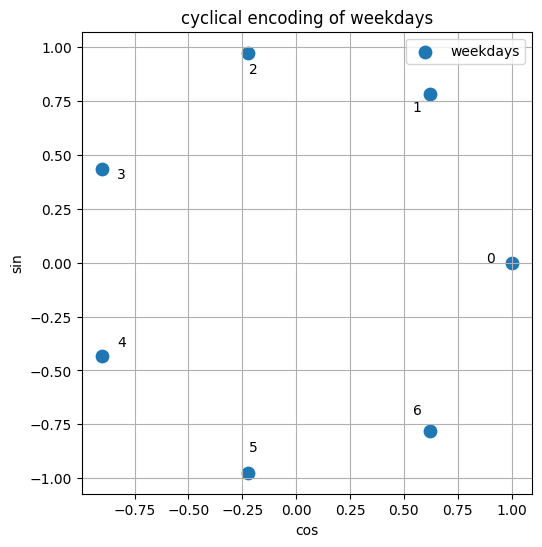

In [44]:
count = 7

# cyclical encoding for weekdays
value = np.arange(count)
angles = 2 * np.pi * value / count
sin_vals = np.sin(angles)
cos_vals = np.cos(angles)

plt.figure(figsize=(6,6))

# scatter + label for legend
plt.scatter(cos_vals, sin_vals, s=80, label='weekdays')

# activate grid 
plt.grid(True)

# Punkte beschriften
for i in range(count):
    plt.text(cos_vals[i] * 0.9, sin_vals[i] * 0.9, str(i), ha='center')

# axis and title
plt.title("cyclical encoding of weekdays")
plt.xlabel("cos")
plt.ylabel("sin")

# display circle evenly
plt.gca().set_aspect('equal')

# create legend
plt.legend()

plt.show()

### 5.4 - create column weekend/bridging day
- weekend 
    - 0 -> it's not the weekend (monday to friday)
    - 1 -> it's the weekend (saturday + sunday)
- bridging day
    - 0 -> no
    - 1 -> yes -> if thursday is holiday, then friday is a bridging day (tuesday holiday -> monday bridging day)

In [45]:
df_load_15min_clean["weekend"] = 0
df_load_15min_clean.loc[(df_load_15min_clean["weekday"] >= 5), "weekend"] = 1
df_load_15min_clean.head(-5)
df_load_15min_clean["weekend"].value_counts()

weekend
0    53760
1    21400
Name: count, dtype: int64

Let's check if ->  **saturdays + sundays = weekend days**

In [46]:
weekend_days = df_load_15min_clean["weekend"][df_load_15min_clean["weekend"] == 1].count()
sat_sun_days = df_load_15min_clean["weekday"][(df_load_15min_clean["weekday"] >= 5)].count()

print(f"weekend days in dataset: {weekend_days}")
print(f"saturdays/sundays in dataset: {sat_sun_days}")
print(weekend_days==sat_sun_days)

weekend days in dataset: 21400
saturdays/sundays in dataset: 21400
True


### 5.5 - create shifts (early, late, night and shift change)
- early shift -> 6 a.m. to 2 p.m
- late shift -> 2 p.m. to 10 p.m
- early shift -> 10 p.m. to 6 a.m.


In [47]:
df_load_15min_clean["early_shift"] = 0
df_load_15min_clean["late_shift"] = 0
df_load_15min_clean["night_shift"] = 0
df_load_15min_clean.loc[(df_load_15min_clean.index.hour >= 6) & (df_load_15min_clean.index.hour < 14),"early_shift"] = 1
df_load_15min_clean.loc[(df_load_15min_clean.index.hour >= 14) & (df_load_15min_clean.index.hour < 22),"late_shift"] = 1
df_load_15min_clean.loc[(df_load_15min_clean.index.hour >= 22) | (df_load_15min_clean.index.hour < 6),"night_shift"] = 1
df_load_15min_clean.head()

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1


In [48]:
time_sc_el = 14     # time when shift changes from early shift to late shift
time_sc_ln = 22     # time when shift changes from late shift to night shift
time_sc_ln = 6      # time when shift changes from night shift to early shift
time_sc_diff = 1    # 1h -> do not change!!!

shiftchange_el = (df_load_15min_clean.index.hour >= time_sc_el - time_sc_diff) & (df_load_15min_clean.index.hour < time_sc_el + time_sc_diff)
shiftchange_ln = (df_load_15min_clean.index.hour >= time_sc_ln - time_sc_diff) & (df_load_15min_clean.index.hour < time_sc_ln + time_sc_diff)
shiftchange_ne = (df_load_15min_clean.index.hour >= time_sc_ln - time_sc_diff) & (df_load_15min_clean.index.hour < time_sc_ln + time_sc_diff)

df_load_15min_clean["shiftchange_el"] = 0
df_load_15min_clean["shiftchange_ln"] = 0
df_load_15min_clean["shiftchange_ne"] = 0


df_load_15min_clean.loc[shiftchange_el,"shiftchange_el"] = 1
df_load_15min_clean.loc[shiftchange_ln,"shiftchange_ln"] = 1
df_load_15min_clean.loc[shiftchange_ne,"shiftchange_ne"] = 1
df_load_15min_clean.head()

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0


### 5.6 - create column holiday/bridging day

In [49]:
# e. g. german holidays for Rhineland-Palatinate
var_holidays = holidays.Germany(years=df_load_15min_clean.index.year.unique(), prov="RP")

# creat column: 1 = holiday, 0 = normal day
df_load_15min_clean["date"] = df_load_15min_clean.index.date    # extract date to compare with the date of the holidays list
df_load_15min_clean["holiday"] = df_load_15min_clean["date"].isin(var_holidays).astype(int)

In [50]:
# creat column: 1 = bridging day, 0 = not a bridging day
holiday_dates = list(var_holidays.keys())  # datetime.date Objekte

bridge_days = set()

for h in holiday_dates:
    # day before the holiday (only if holiday is on tuesday -> the day before is monday)
    prev_day = h - dt.timedelta(days=1)     # subtract one day from the holiday date
    if prev_day.weekday() == 0:  # 0 = monday
        bridge_days.add(prev_day)

    # day after the holiday (only if holiday is on thursday -> the day after is friday)
    next_day = h + dt.timedelta(days=1)     # add one day to the holiday date
    if next_day.weekday() == 4:  # 4 = friday
        bridge_days.add(next_day)

bridge_days = sorted(list(bridge_days))


df_load_15min_clean["bridging_day"] = (df_load_15min_clean["date"].isin(bridge_days)).astype(int)

In [51]:
# print holidays in a specified year (only if they exist in the dataset)
year = 2024

holiday_dates_year = (
    df_load_15min_clean
        .loc[
            (df_load_15min_clean["holiday"] == 1) &
            (df_load_15min_clean.index.year == year)
        ]
        .index
        .date
)

# Duplikate entfernen (weil 15-Minuten-Auflösung)
holiday_dates_year_unique = sorted(list(set(holiday_dates_year)))

# Anzahl
count_of_holidays = len(holiday_dates_year_unique)

print(count_of_holidays)
display(holiday_dates_year_unique)


10


[datetime.date(2024, 3, 29),
 datetime.date(2024, 4, 1),
 datetime.date(2024, 5, 1),
 datetime.date(2024, 5, 9),
 datetime.date(2024, 5, 20),
 datetime.date(2024, 5, 30),
 datetime.date(2024, 10, 3),
 datetime.date(2024, 11, 1),
 datetime.date(2024, 12, 25),
 datetime.date(2024, 12, 26)]

In [52]:
# print bridging days in a specified year (only if they exist in the dataset)
year = 2024

bringing_day_dates_year = (
    df_load_15min_clean
        .loc[
            (df_load_15min_clean["bridging_day"] == 1) &
            (df_load_15min_clean.index.year == year)
        ]
        .index
        .date
)

# Duplikate entfernen (weil 15-Minuten-Auflösung)
bringing_day_dates_year_unique = sorted(list(set(bringing_day_dates_year)))

# Anzahl
count_of_bridging_days = len(bringing_day_dates_year_unique)

print(count_of_bridging_days)
display(bringing_day_dates_year_unique)

4


[datetime.date(2024, 5, 10),
 datetime.date(2024, 5, 31),
 datetime.date(2024, 10, 4),
 datetime.date(2024, 12, 27)]

### 5.7. - finished feature engineering -> now check the final DataFrame and save it as CSV

#### 5.7.1 - save data as CSV-file and load again as "df"

In [53]:
df_load_15min_clean.to_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28_cleaned.csv", index=True)
df = pd.read_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28_cleaned.csv",
                index_col=0,
                parse_dates=True
                )


#### 5.7.2 - first 5 rows

In [54]:
df.iloc[:5]

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,date,holiday,bridging_day
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0


#### 5.7.3 - last 5 rows

In [55]:
df.iloc[-5:]

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,date,holiday,bridging_day
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-02-28 22:45:00,11430,22,45,1365,2,1,-0.500000,0.866025,-1.000000e+00,-1.836970e-16,-0.321439,0.946930,0.004363,0.99999,0.0,1.0,11460,11670,12460,10500,11750.000000,11795.416667,11929.583333,343.696483,405.194308,465.069010,5,False,False,False,False,False,True,False,-0.974928,-0.222521,1,0,0,1,0,0,0,2026-02-28,0,0
2026-02-28 23:00:00,11260,23,0,1380,2,1,-0.258819,0.965926,0.000000e+00,1.000000e+00,-0.258819,0.965926,0.004363,0.99999,0.0,1.0,11600,11510,12280,10960,11658.333333,11797.916667,11913.125000,311.384980,401.529458,474.597954,5,False,False,False,False,False,True,False,-0.974928,-0.222521,1,0,0,1,0,0,0,2026-02-28,0,0
2026-02-28 23:15:00,11090,23,15,1395,2,1,-0.258819,0.965926,1.000000e+00,2.832769e-16,-0.195090,0.980785,0.004363,0.99999,0.0,1.0,11960,11470,12310,11290,11563.333333,11789.583333,11883.750000,294.566965,414.398245,481.091954,5,False,False,False,False,False,True,False,-0.974928,-0.222521,1,0,0,1,0,0,0,2026-02-28,0,0
2026-02-28 23:30:00,11160,23,30,1410,2,1,-0.258819,0.965926,5.665539e-16,-1.000000e+00,-0.130526,0.991445,0.004363,0.99999,0.0,1.0,11620,11480,12240,11490,11475.833333,11759.583333,11860.416667,234.925843,433.203227,488.566981,5,False,False,False,False,False,True,False,-0.974928,-0.222521,1,0,0,1,0,0,0,2026-02-28,0,0
2026-02-28 23:45:00,11000,23,45,1425,2,1,-0.258819,0.965926,-1.000000e+00,-1.836970e-16,-0.065403,0.997859,0.004363,0.99999,0.0,1.0,11430,11460,12220,11460,11420.000000,11712.500000,11836.041667,262.574665,452.185514,501.799907,5,False,False,False,False,False,True,False,-0.974928,-0.222521,1,0,0,1,0,0,0,2026-02-28,0,0


## 6. - EDA part 2

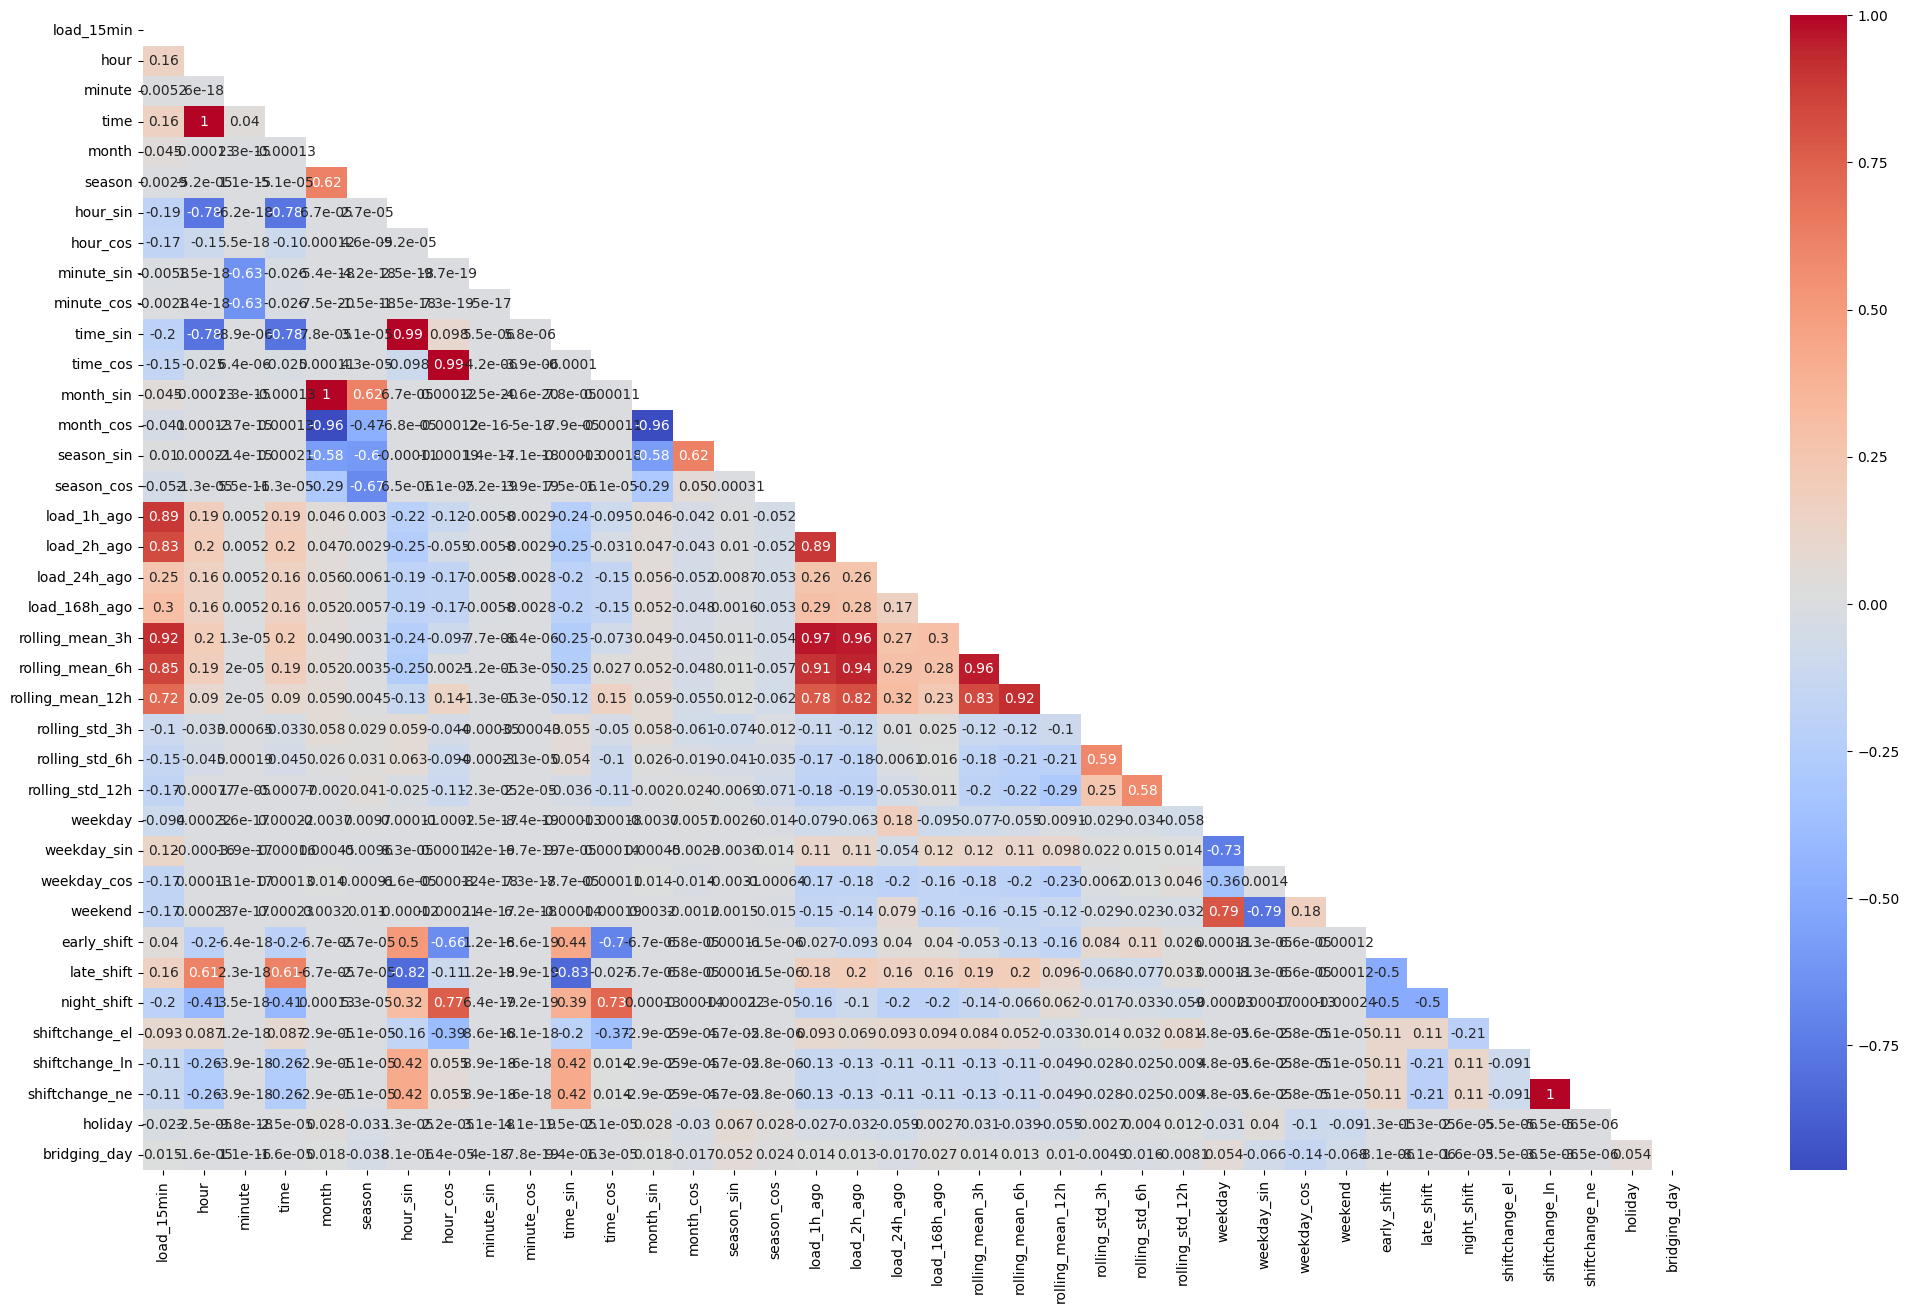

In [56]:
cat = df.select_dtypes(exclude="number")
num = df.select_dtypes(include="number")

correlation_matrix = num.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(25, 15))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

#plt.title("Dealing with Multicollinearity")
plt.show()

In [57]:
keep_columns = ["load_15min",
    
                "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago", 
                "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
                "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
                
                "time",
                "time_sin",
                "time_cos",

                # "hour",
                "hour_sin", "hour_cos",

                # "minute",
                "minute_sin", "minute_cos",

                # "month",
                "month_sin", "month_cos",

                # "season",
                "season_sin", "season_cos",

                # "weekday",
                "weekday_sin", "weekday_cos",
                "weekend",

                "holiday", "bridging_day",

                "early_shift", "late_shift", "night_shift",
                "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
                ]

df = df[keep_columns]

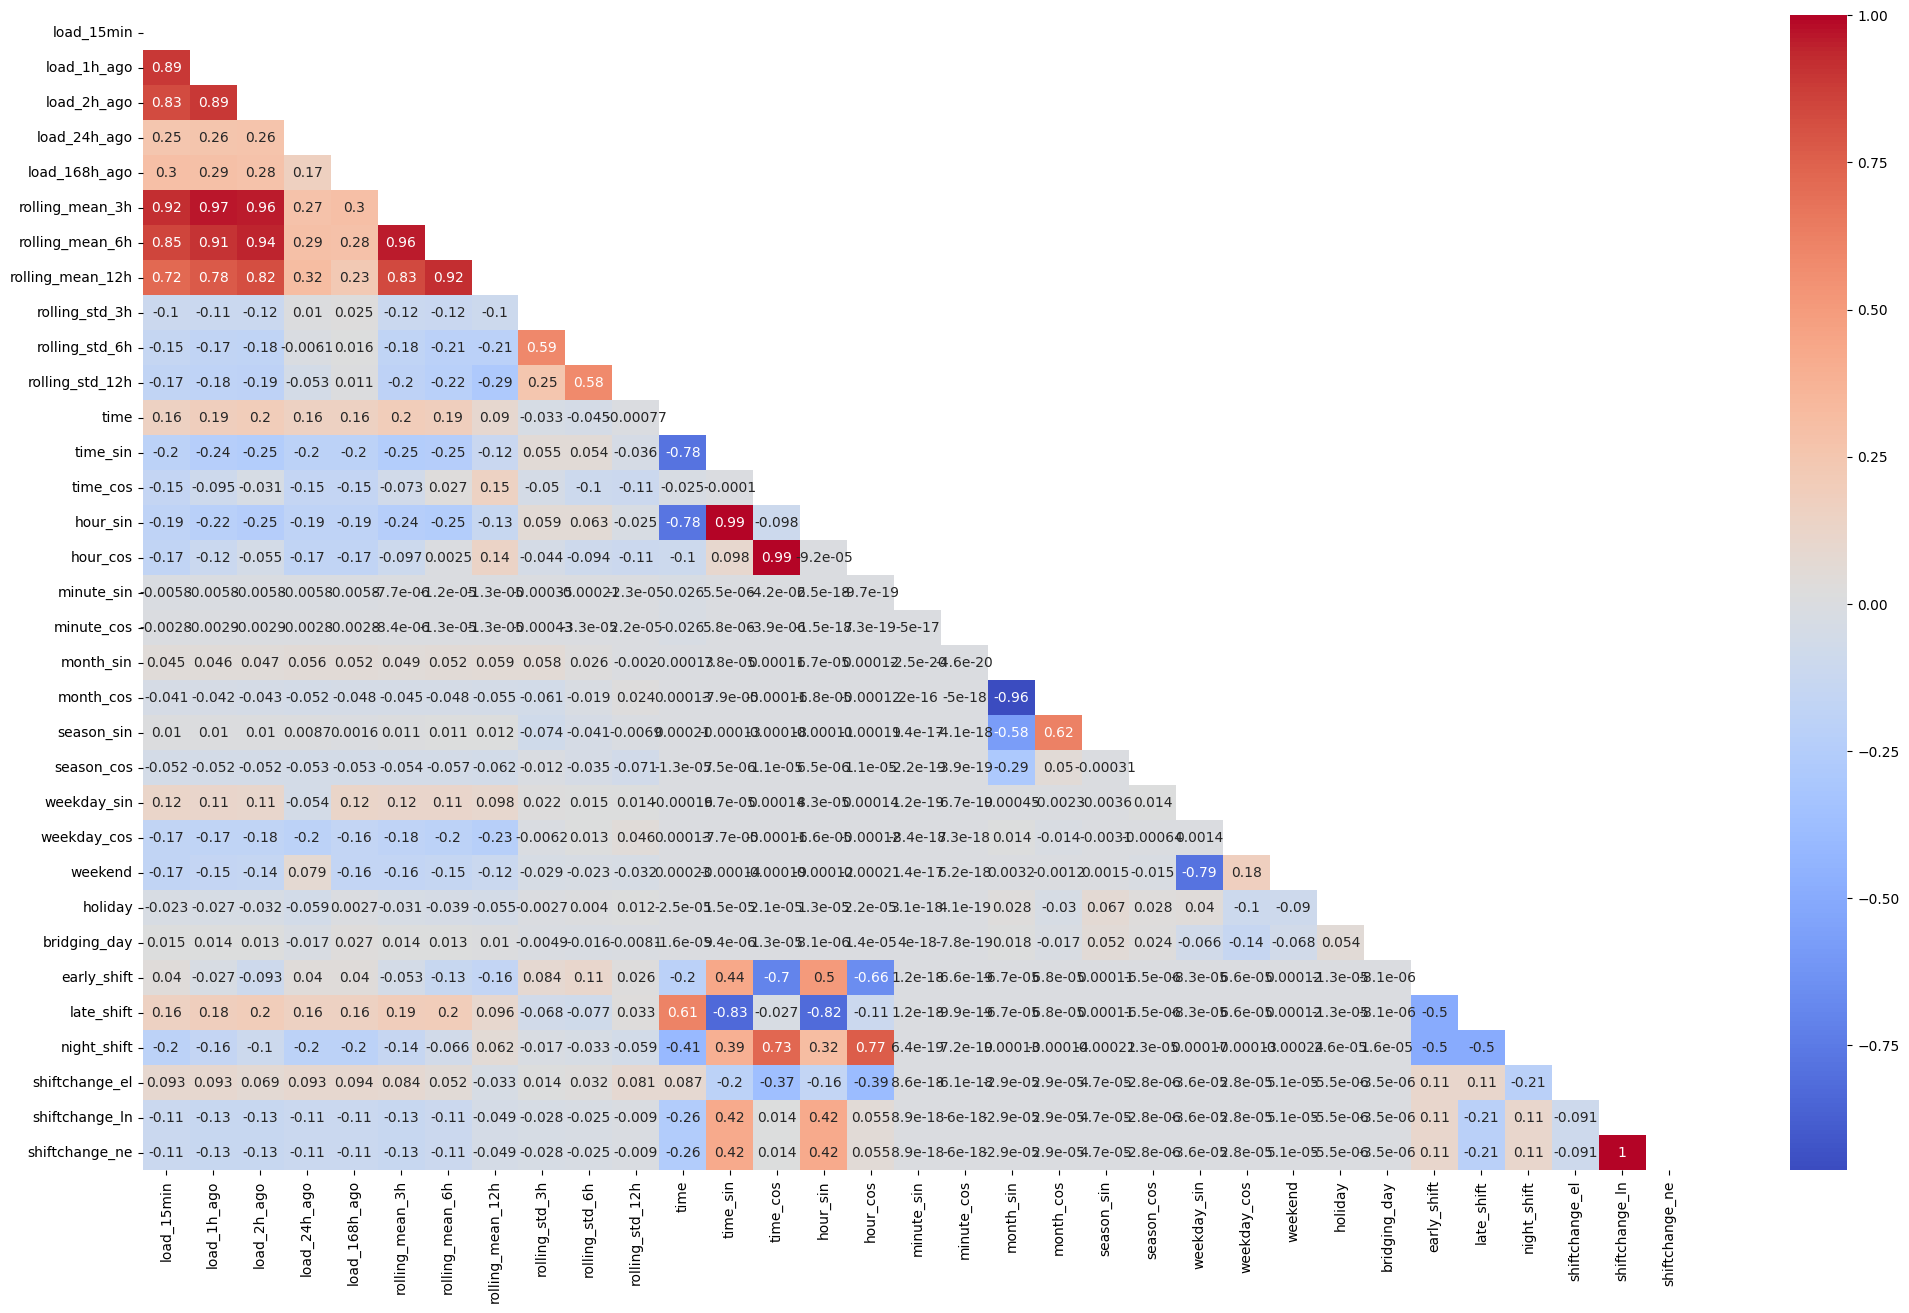

In [58]:
correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(25, 15))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

#plt.title("Dealing with Multicollinearity")
plt.show()